# UMAP

In [3]:
from smiles_gen_new import peptide_smiles
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import rdMolDraw2D
import re
import umap
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

from compile_friedman import plot_rank_heatmap
fingergen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


/opt/miniconda3/envs/chemprop/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
#importing data for umap
base_dir = '/Users/emily/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Peptide Research - Shared/Data/git_data_vf/final_training_data'

new_1M = pd.read_csv(f'{base_dir}/pretraining/new_1M.csv')
hemo = pd.read_csv(f'{base_dir}/chemberta_hemolysis_chemprop_550.csv')
camsol = pd.read_csv(f'{base_dir}/even_chemberta_noncanonical_camsol_chemprop_10k.csv')
syn = pd.read_csv(f'{base_dir}/synthesize_chemprop.csv')

In [6]:
#canonical categorizing

CANONICAL_AAS = set("ACDEFGHIKLMNPQRSTVWY")
SPECIAL_TOKENS = {"[AMD]"}

def categorise_sequence(seq: str):
    bracketed = set(re.findall(r'\[[^\]]+\]', seq))
    noncanonical_brackets = bracketed - SPECIAL_TOKENS
    if noncanonical_brackets:
        return "Non-natural"
    stripped = re.sub(r'\[[^\]]+\]', '', seq)
    noncanonical_chars = set(stripped) - CANONICAL_AAS
    if noncanonical_chars:
        return "Non-natural"

    return "Natural"

def smiles_to_fingerprint(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return fingergen.GetFingerprintAsNumPy(mol)

In [7]:
def add_fingerprints(df, seq_col='linear_SMILES'):
    df = df.copy()
    df['Morgan_linear'] = df[seq_col].apply(smiles_to_fingerprint)
    return df

def add_umap_cols(df, embedding, index):
    return pd.concat([df, pd.DataFrame(embedding, index=index,
                                        columns=['UMAP_0_expfirst', 'UMAP_1_expfirst'])], axis=1)

# Combine experimental sets and tag canonical status
exp = pd.concat([hemo, syn, camsol], ignore_index=True)
exp['canonical_status'] = exp['Consolidated_Sequences'].apply(categorise_sequence)
new_1M['canonical_status'] = "Natural"
all_data = pd.concat([new_1M, exp], ignore_index=True)

# Fit UMAP on experimental (non-generated) data
exp_only = add_fingerprints(all_data[all_data['class'] != 'generated_canonical'])
X_exp = np.vstack(exp_only['Morgan_linear'])

reducer = umap.UMAP(n_components=2, metric='jaccard', random_state=42, verbose=True)
reducer.fit(X_exp)
exp_umap = add_umap_cols(exp_only, reducer.embedding_, exp_only.index)

# Project generated sequences into the same UMAP space
gen_can = add_fingerprints(all_data[all_data['class'] == 'generated_canonical'])
X_gen = np.vstack(gen_can['Morgan_linear'])
gen_umap = add_umap_cols(gen_can, reducer.transform(X_gen), gen_can.index)

new_all = pd.concat([gen_umap, exp_umap], ignore_index=True)

/opt/miniconda3/envs/chemprop/lib/python3.14/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/miniconda3/envs/chemprop/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP(angular_rp_forest=True, metric='jaccard', n_jobs=1, random_state=42, verbose=True)
Tue Aug 18 03:23:41 2026 Construct fuzzy simplicial set
Tue Aug 18 03:23:41 2026 Finding Nearest Neighbors
Tue Aug 18 03:23:41 2026 Building RP forest with 11 trees
Tue Aug 18 03:23:43 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	 5  /  14
	Stopping threshold met -- exiting after 5 iterations
Tue Aug 18 03:23:51 2026 Finished Nearest Neighbor Search
Tue Aug 18 03:23:52 2026 Construct embedding


Epochs completed:   4%| ▍          9/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  14%| █▍         29/200 [00:01]

...

Epochs completed:  83%| ████████▎  25/30 [00:35]

	completed  24  /  30 epochs


Epochs completed:  97%| █████████▋ 29/30 [00:41]

	completed  27  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [00:42]


In [13]:
def parse_fasta(path):
    header = None
    seq_chunks = []
    with open(path) as f:
        for line in f:
            line = line.rstrip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq_chunks)
                header = line[1:].strip()
                seq_chunks = []
            else:
                seq_chunks.append(line)
    if header is not None:
        yield header, "".join(seq_chunks)

def add_smiles_and_fingerprints(df, seq_col="Consolidated_Sequences"):
    df = df.copy()
    df["linear_SMILES"] = df[seq_col].apply(peptide_smiles)
    df["Morgan_linear"] = df["linear_SMILES"].apply(
        lambda s: smiles_to_fingerprint(s) if s is not None else None
    )
    return df

In [83]:
peptipedia = parse_fasta('./all_peptides.fasta')
peptipedia_smiles = add_smiles_and_fingerprints(peptipedia)
peptipedia_smiles['class'] = 'peptipedia_smiles'
peptipedia_smiles = peptipedia_smiles.drop_duplicates(['Consolidated_Sequences'])
peptipedia_smiles['canonical_status'] = peptipedia_smiles['canonical_status'] = peptipedia_smiles['Consolidated_Sequences'].apply(categorise_sequence)

peptipedia_smiles['seq_len'] = peptipedia_smiles['Consolidated_Sequences'].str.len()
peptipedia_smiles_filtered = peptipedia_smiles[peptipedia_smiles['seq_len'].between(5, 35)]
peptipedia_smiles_filtered = peptipedia_smiles[peptipedia_smiles['canonical_status'] == 'Natural']

(2908467, 9)

In [84]:
# Project generated sequences into the same UMAP space
pep_stack = np.vstack(peptipedia_smiles_filtered['Morgan_linear'])
pep_umap = add_umap_cols(peptipedia_smiles_filtered, reducer.transform(pep_stack), peptipedia_smiles_filtered.index)

Epochs completed:   7%| ▋          2/30 [00:01]

	completed  0  /  30 epochs


Epochs completed:  13%| █▎         4/30 [00:10]

	completed  3  /  30 epochs


Epochs completed:  27%| ██▋        8/30 [00:28]

...

Epochs completed:  83%| ████████▎  25/30 [01:41]

	completed  24  /  30 epochs


Epochs completed:  97%| █████████▋ 29/30 [01:59]

	completed  27  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [02:03]


In [89]:
new_all_2 = pd.concat([gen_umap, exp_umap, pep_umap], ignore_index=True)
new_all_2 = new_all_2.dropna(subset=["UMAP_0_expfirst", "UMAP_1_expfirst"])
new_all_2 = new_all_2[np.isfinite(new_all_2["UMAP_0_expfirst"]) & np.isfinite(new_all_2["UMAP_1_expfirst"])]
new_all_2["UMAP_0_expfirst"] = new_all_2["UMAP_0_expfirst"].astype(np.float64)
new_all_2["UMAP_1_expfirst"] = new_all_2["UMAP_1_expfirst"].astype(np.float64)

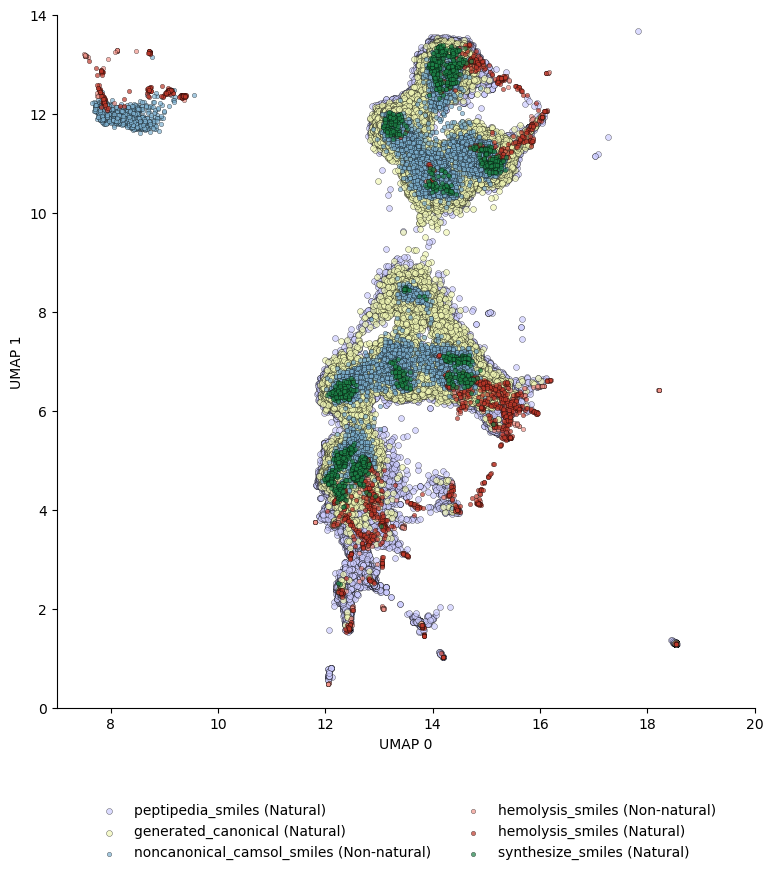

In [97]:
#umap plot of new1M + peptipedia projected on chemical space of finetuning datasets
axes_size_small = 16
CLASS_COLORS = {
    "peptipedia_smiles" : {"Natural": "#CCCCFF", "Non-natural": "#CCCCFF"},
    "generated_canonical": {"Natural": "#F1F7B5", "Non-natural": "#F1F7B5"},
    "hemolysis_smiles":          {"Natural": "#C0392B", "Non-natural": "#F1948A"},
    "synthesize_smiles":         {"Natural": "#1E8449", "Non-natural": "#82E0AA"},
    "noncanonical_camsol_smiles": {"Natural": "#1A5276", "Non-natural": "#7FB3D3"},
}

CLASS_MARKER_SIZE = {
    "peptipedia_smiles": 18,
    "generated_canonical": 18,
    "hemolysis_smiles": 10,
    "synthesize_smiles": 10,
    "noncanonical_camsol_smiles": 10,
}

fig = go.Figure()

PLOT_ORDER = [
    ("peptipedia_smiles", "Natural"),
    ("generated_canonical",        "Natural"),
    ("noncanonical_camsol_smiles", "Non-natural"),
    ("hemolysis_smiles",           "Non-natural"),
    ("synthesize_smiles",          "Non-natural"),
    ("noncanonical_camsol_smiles", "Natural"),
    ("hemolysis_smiles",           "Natural"),
    ("synthesize_smiles",          "Natural"),
]


import matplotlib.pyplot as plt

fig_mpl, ax = plt.subplots(figsize=(9, 9))

for cls, canon_val in PLOT_ORDER:
    mask = (new_all_2["class"] == cls) & (new_all_2["canonical_status"] == canon_val)
    sub = new_all_2[mask]
    if sub.empty:
        continue
    color = CLASS_COLORS.get(cls, {}).get(canon_val, "grey")
    size = CLASS_MARKER_SIZE.get(cls, 10)
    ax.scatter(sub["UMAP_0_expfirst"], sub["UMAP_1_expfirst"],
               c=color, s=size, alpha=0.7, edgecolors="black", linewidths=0.3,
               label=f"{cls} ({canon_val})")

ax.set_xlabel("UMAP 0")
ax.set_ylabel("UMAP 1")
ax.set_aspect('auto')  # explicit, avoids UMAP-axis distortion from auto-equal aspect
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(7, 20)
ax.set_ylim(0, 14)

plt.savefig("peptipedia_umap_with_pretrained_exp_first.png", dpi=600, bbox_inches='tight')
plt.show()

In [98]:
new_all_2['class'].value_counts()

class
peptipedia_smiles             2908467
generated_canonical           1000000
noncanonical_camsol_smiles      10000
hemolysis_smiles                 2000
synthesize_smiles                1771
Name: count, dtype: int64

In [96]:
#creating SMILES structures for supplementary figure of non-natural amino acids used during exp. synthesis
smiles = {
    'ivdde': 'O=C(OCC1C=2C=CC=CC2C=3C=CC=CC31)NC(C(=O)O)CNC(=C4C(=O)CC(C)(C)CC4=O)CC(C)C',
    'chg':   'O=C(OCC1C=2C=CC=CC2C=3C=CC=CC31)NC(C(=O)O)C4CCCCC4',
    'cha':   'O=C(OCC1C=2C=CC=CC2C=3C=CC=CC31)NC(C(=O)O)CC4CCCCC4',
    'aib':   'O=C(OCC1C=2C=CC=CC2C=3C=CC=CC31)NC(C(=O)O)(C)C',
    'nle': 'O=C(OCC1C=2C=CC=CC2C=3C=CC=CC31)NC(C(=O)O)CCCC',
}

for name, smi in smiles.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"FAILED to parse: {name}")
        continue
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 500)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    with open(f"{name}.svg", "w") as f:
        f.write(svg)

In [ ]:
#subplots of distributions
fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.07)
# Combine experimental sets and tag canonical status
exp = pd.concat([hemo, syn, camsol], ignore_index=True)
hemo['canonical_status'] = hemo['Consolidated_Sequences'].apply(categorise_sequence)
syn['canonical_status'] = syn['Consolidated_Sequences'].apply(categorise_sequence)
camsol['canonical_status'] = camsol['Consolidated_Sequences'].apply(categorise_sequence)



for canon_val in ["Non-natural", "Natural"]:
    sub   = syn[syn["canonical_status"] == canon_val]
    color = CLASS_COLORS["synthesize_smiles"][canon_val]
    fig.add_trace(go.Histogram(
        x=sub["L : (L+M) Ratio (%)"],
        name=f"synthesizability ({canon_val})",
        marker=dict(color=color, line=dict(width=0.5, color="black")),
        opacity=0.85,
    ), row=1, col=1)

for canon_val in ["Non-natural", "Natural"]:
    sub   = camsol[camsol["canonical_status"] == canon_val]
    color = CLASS_COLORS["noncanonical_camsol_smiles"][canon_val]
    fig.add_trace(go.Histogram(
        x=sub["camsol_score"],
        name=f"camsol ({canon_val})",
        marker=dict(color=color, line=dict(width=0.5, color="black")),
        opacity=0.85,
    ), row=1, col=2)

for canon_val in ["Non-natural", "Natural"]:
    sub   = hemo[hemo["canonical_status"] == canon_val]
    color = CLASS_COLORS["hemolysis_smiles"][canon_val]
    fig.add_trace(go.Histogram(
        x=sub["revised_50hemo"],
        name=f"hemolysis ({canon_val})",
        marker=dict(color=color, line=dict(width=0.5, color="black")),
        opacity=0.85,
    ), row=1, col=3)

fig.update_layout(
    barmode="stack",
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    bargap=0.05,
    showlegend=False,
    width=1400,
    height=500,
)

axes_size = 24
axes_size_small = 20
for col in range(1, 4):
    fig.update_xaxes(showline=True, linecolor="black", mirror=True, ticks="outside",
                     showgrid=False, tickfont=dict(size=18, family="Aptos"), title_font=dict(size=axes_size_small),
                     row=1, col=col)
    fig.update_yaxes(showline=True, linecolor="black", mirror=True, ticks="outside",
                     showgrid=False, tickfont=dict(size=18,family="Aptos"), title_font=dict(size=axes_size_small),
                     row=1, col=col)

fig.update_yaxes(title_text="Count",title_font=dict(size=axes_size, family="Aptos"), title_standoff=5, row=1, col=1)
fig.update_yaxes(title_text="Count",title_font=dict(size=axes_size, family="Aptos"), title_standoff=5, row=1, col=2)
fig.update_yaxes(title_text="Count",title_font=dict(size=axes_size, family="Aptos"), title_standoff=5, row=1, col=3)

fig.update_xaxes(title_text="[] (µM)",title_font=dict(size=axes_size, family="Aptos"), title_standoff=5, row=1, col=3)
fig.update_xaxes(title_text="Purity (%) ",title_font=dict(size=axes_size, family="Aptos"),title_standoff=5, row=1, col=1)
fig.update_xaxes(title_text="CamSol Score",title_font=dict(size=axes_size, family="Aptos"), title_standoff=5,row=1, col=2)

fig.write_image("bar.svg")

In [ ]:
#grouped bar chart for test pearson visualization
CSV_PATH = "./new_table_combined_long.csv"

df_all = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df_all.columns = df_all.columns.str.strip()
df = df_all[df_all["Split"] == "Random"]

DATASETS = ["Synthesizability", "Non-natural CamSol", "Hemolysis"]
COL = "Pearson Correlation Test"
Y_LABEL = "Test Pearson r"

GROUP_ORDER = ["Classical Regression", "Molecular Graphs", "Language Models"]
SUBCAT_ORDER = [
    "Single-task",
    "Multi-task",
    "Multi-task (Pretrained)",
    "Multi-task (Pretrained, Frozen Encoder)"
]

# raw model name -> (group, base model, subcategory, short x-axis label)
MODEL_INFO = {
    "SVM":                                                   ("Classical Regression", "SVM",           None, "SVM"),
    "XGBoost":                                                ("Classical Regression", "XGBoost",       None, "XGBoost"),
    "Random Forest":                                          ("Classical Regression", "Random Forest", None, "RF"),
    "CatBoost":                                               ("Classical Regression", "CatBoost",      None, "CatBoost"),

    "Chemeleon (Single-task)":                                ("Molecular Graphs", "Chemeleon", "Single-task", "Chemeleon"),
    "ChemProp (Single-task)":                                 ("Molecular Graphs", "ChemProp",  "Single-task", "ChemProp"),
    "Chemeleon (Multi-head)":                                 ("Molecular Graphs", "Chemeleon", "Multi-task", "Chemeleon"),
    "ChemProp (Multi-head)":                                  ("Molecular Graphs", "ChemProp",  "Multi-task", "ChemProp"),
    "ChemProp (Multi-head, Pretrained)":                      ("Molecular Graphs", "ChemProp",  "Multi-task (Pretrained)", "ChemProp"),
    "ChemProp (Multi-head, Pretrained Frozen Encoder HPO)": ("Molecular Graphs", "ChemProp", "Multi-task (Pretrained, Frozen Encoder)", "ChemProp"),

    "PepDoRA (Single-task)":                                  ("Language Models", "PepDoRA",   "Single-task", "PepDoRA"),
    "ChemBERTa-77M-MTR (Single-task)":                        ("Language Models", "ChemBERTa", "Single-task", "ChemBERTa"),
    "PepDoRA":                                                ("Language Models", "PepDoRA",   "Multi-task", "PepDoRA"),
    "ChemBERTa-77M-MTR":                                      ("Language Models", "ChemBERTa", "Multi-task", "ChemBERTa"),
    "LoRA ChemBERTa-77M-MTR":                                 ("Language Models", "ChemBERTa", "Multi-task (Pretrained)", "ChemBERTa"),
}

BASE_COLORS = {
    "SVM":           "#FFE0B2",
    "XGBoost":       "#FFB74D",
    "Random Forest": "#FB8C00",
    "CatBoost":      "#E65100",
    "Chemeleon":     "#2E7D32",
    "ChemProp":      "#1565C0",
    "PepDoRA":       "#6A1B9A",
    "ChemBERTa":     "#AD1457",
}

PATTERN_MAP = {
    None:                                      "",
    "Single-task":                             "",
    "Multi-task":                              "",
    "Multi-task (Pretrained)":                 "x",
    "Multi-task (Pretrained, Frozen Encoder)": ".",
}

HIGHLIGHT_MODELS = {
    "ChemProp (Multi-head, Pretrained)",
    "ChemProp (Multi-head, Pretrained Frozen Encoder HPO)",
    "PepDoRA",
    "ChemBERTa-77M-MTR",
    "LoRA ChemBERTa-77M-MTR",
}

models_by_group_subcat = {
    group: {
        subcat: [m for m, info in MODEL_INFO.items() if info[0] == group and info[2] == subcat]
        for subcat in (SUBCAT_ORDER if group != "Classical Regression" else [None])
    }
    for group in GROUP_ORDER
}

# y-axis range per dataset row, padded for external text labels
row_y_ranges = {}
for ds in DATASETS:
    vals = df[df["Dataset"] == ds][COL].dropna()
    if vals.empty:
        row_y_ranges[ds] = None
        continue
    pad = (vals.max() - vals.min()) * 0.10 if vals.max() > vals.min() else 1.0
    y_hi = vals.max() + pad
    row_y_ranges[ds] = [0, y_hi + y_hi * 0.15]

fig = make_subplots(rows=3, cols=3, horizontal_spacing=0.1, vertical_spacing=0.07)

for r, ds in enumerate(DATASETS):
    sub = df[df["Dataset"] == ds]

    for c, group_name in enumerate(GROUP_ORDER):
        for subcat, models in models_by_group_subcat[group_name].items():
            x_vals, y_vals, fill_colors, edge_colors, edge_widths, patterns = [], [], [], [], [], []
            for model in models:
                _, base, _, short_label = MODEL_INFO[model]
                row = sub[sub["Model"] == model]
                if row.empty or pd.isna(row[COL].iloc[0]):
                    continue

                base_color = BASE_COLORS[base]
                highlighted = model in HIGHLIGHT_MODELS

                x_vals.append(short_label)
                y_vals.append(float(row[COL].iloc[0]))
                patterns.append(PATTERN_MAP[subcat])

                if subcat in ("Single-task", None):
                    fill_colors.append("white")
                    edge_colors.append("black" if highlighted else base_color)
                    edge_widths.append(2.5 if highlighted else 7.5)
                else:
                    fill_colors.append(base_color)
                    edge_colors.append("black")
                    edge_widths.append(5 if highlighted else 0.5)

            if not x_vals:
                continue

            fig.add_trace(go.Bar(
                x=x_vals,
                y=y_vals,
                text=[f"{v:.2f}" for v in y_vals],
                textposition="outside",
                textfont=dict(size=20, family="Aptos"),
                marker=dict(color=fill_colors, pattern_shape=patterns,
                            line=dict(color=edge_colors, width=edge_widths)),
                showlegend=False,
            ), row=r + 1, col=c + 1)

for subcat in SUBCAT_ORDER:
    swatch_color = "white" if subcat == "Single-task" else "#BDBDBD"
    fig.add_trace(go.Bar(x=[None], y=[None],
                          marker=dict(color=swatch_color, pattern_shape=PATTERN_MAP[subcat],
                                      line=dict(color="black", width=1)),
                          name=subcat, legendgroup="pattern", showlegend=True), row=1, col=1)

fig.update_layout(
    barmode="group",
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    bargap=0.15,
    showlegend=True,
    legend=dict(orientation="h", x=0.5, y=1.12, xanchor="center", yanchor="bottom"),
    width=1800,
    height=1200,
)

fig.update_xaxes(showline=True, linecolor="black", mirror=True, ticks="outside",
                 showgrid=False, tickfont=dict(size=24, family="Aptos"), title_font=dict(size=24))
fig.update_yaxes(showline=True, linecolor="black", mirror=True, ticks="outside",
                 showgrid=False, tickfont=dict(size=22, family="Aptos"), title_font=dict(size=24))

for r, ds in enumerate(DATASETS):
    fig.update_yaxes(range=row_y_ranges[ds], row=r + 1)
    fig.update_yaxes(title_text=ds, title_font=dict(size=28, family="Aptos"), title_standoff=10, row=r + 1, col=1)

fig.update_layout(annotations=list(fig.layout.annotations) + [
    dict(text=f"{Y_LABEL} (Random split)", x=0.5, y=-0.08, xref="paper", yref="paper",
         showarrow=False, font=dict(size=28, family="Aptos"))
])

fig.write_image("bar_scores_pearson_test_random.svg")

In [ ]:
#chromatogram graphs color coded by sample type
LABEL_COLORS = {
    "Top1": "#1f77b4",
    "Top2": "#2ca02c",
    "Bottom": "#d62728",
    "Replicate_Control": "#7f7f7f",
    "Control": "#9467bd",
    "Unknown": "#000000",
}

GROUP_XLIMS = {
    "GLP-1": (5, 13),
    "hGH[176-191]F176Y": (3, 10),
    "MYC[123-143]": (3, 10),
    "Barstar[75-90]": (4.5, 10.5),
    "GHRH": (4.5, 10.5),
}

YLIM = (0, 420000)


def plot_overlay_grid(df, wavelength=220, out_path=None):
    subset = df[df["Wavelength_nm"] == str(wavelength)]
    groups = list(GROUP_XLIMS.keys())

    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 5), sharey=True)
    fig.patch.set_alpha(0.0)

    for ax, group in zip(axes, groups):
        for sample, sub in subset[subset["group"] == group].groupby("sample"):
            color = LABEL_COLORS.get(sub["label"].iloc[0], LABEL_COLORS["Unknown"])
            ax.plot(sub["Time_min"], sub["Intensity"], color=color, linewidth=1)

        ax.set_xlim(GROUP_XLIMS[group])
        ax.set_ylim(YLIM)
        ax.set_title(group, fontsize=18)
        ax.set_xlabel("Retention Time (min)", fontsize=16)
        ax.set_facecolor("none")
        ax.tick_params(labelsize=13)

    axes[0].set_ylabel("Intensity (mAU)", fontsize=16)

    present_labels = [l for l in ["Top1", "Top2", "Bottom", "Replicate_Control", "Control"] if l in subset["label"].unique()]
    handles = [plt.Line2D([], [], color=LABEL_COLORS[l], label=l) for l in present_labels]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               bbox_to_anchor=(0.5, -0.05), fontsize=14, frameon=False)

    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight", transparent=True)
    return fig, axes


compiled_chromatogram = '.chromatograms_cleaned.csv'
fig, axes = plot_overlay_grid(compiled_chromatogram, wavelength=220)
fig.savefig("combined_chromatograms.svg", transparent=True)
plt.show()

In [ ]:
#creating friedman ranking and then plotting mean values on a heatmap
!python compile_friedman.py --input-dir "./fold_jsons_friedman" --alpha 0.05

mr = pd.read_csv('mean_ranks.csv')
fr = pd.read_csv('friedman_results.csv')
properties = ['camsol', 'hemolysis', 'synthesizability']

plot_rank_heatmap(mr, fr, 'group', properties, 'heatmap_group.svg', top_n=15)
plot_rank_heatmap(mr, fr, 'random', properties, 'heatmap_random.svg', top_n=15)